# Explorations

In [2]:
# Dates management
import datetime

import numpy as np

import matplotlib.pyplot as plt
# Visualization library
import altair as alt

# Data manipulation library
import pandas as pd

# Enable Altair to display all rows of data
alt.data_transformers.enable('default', max_rows=None)


DataTransformerRegistry.enable('default')

In [3]:
%load_ext autoreload
%autoreload 2

dataframe.to_pickle()

In [4]:

# Chargement des differets dataframes
df_person = pd.read_pickle('datap/df_person.pkl')
df_person.info()
df_person.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   birth_datetime       1547 non-null   datetime64[ns]
 1   death_datetime       830 non-null    datetime64[ns]
 2   gender_source_value  1547 non-null   object        
 3   cdm_source           1547 non-null   object        
 4   person_id            1547 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(2)
memory usage: 60.6+ KB


,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id
0,1984-11-06,NaT,f,EHR 1,88817330.0
1,1961-03-29,2021-06-07,f,EHR 1,82132985.0
2,1972-08-24,NaT,m,EHR 1,87488498.0
3,1962-12-31,2024-10-19,male,EHR 1,86280490.0
4,1948-09-30,2020-05-27,female,EHR 1,81646230.0


In [5]:
df_condition = pd.read_pickle('datap/df_condition.pkl')
df_condition.info()
df_condition.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2152 entries, 0 to 2151
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   visit_occurrence_id      2152 non-null   float64
 1   person_id                2152 non-null   float64
 2   condition_occurrence_id  2152 non-null   float64
 3   condition_source_value   2152 non-null   object 
dtypes: float64(3), object(1)
memory usage: 67.4+ KB


,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value
0,85319808.0,84829170.0,87142885.0,T51
1,80902406.0,85929376.0,89378651.0,Z720
2,84295593.0,86868894.0,85796828.0,C504
3,84975826.0,85566948.0,81895083.0,F023
4,83844409.0,89203324.0,87313829.0,Z803


In [6]:
df_visit = pd.read_pickle('datap/df_visit.pkl')
df_visit.info()
df_visit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   1547 non-null   float64       
 1   care_site_id          1547 non-null   object        
 2   visit_start_datetime  1547 non-null   datetime64[ns]
 3   visit_end_datetime    1546 non-null   datetime64[ns]
 4   visit_source_value    1547 non-null   object        
 5   person_id             1547 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(2)
memory usage: 72.6+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0
1,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0
2,89802376.0,GHU A.Fleming,2022-03-26,2022-03-27,Hospitalisés,85613365.0
3,81405613.0,Centre F.Sinoussi,2024-07-06,2024-07-07,Hospitalisés,80139607.0
4,80686859.0,Hopital M.Bres,2024-12-30,2025-01-08,Hospitalisés,87634325.0


In [7]:
# Lister toutes les valeurs de l'identifiant ICR-10

df_condition.condition_source_value.value_counts()


condition_source_value
F023    276
G20     264
C19     253
C34     249
Z803    129
C500     96
I13      94
C50      93
I12      87
C502     86
C503     83
C504     74
C501     73
Z587     69
T51      41
Z720     39
K70      32
Z864     31
F10      28
E11      16
Z716     12
E12      11
I15       8
E10       8
Name: count, dtype: int64

In [8]:
# Index des lignes nulles
df_visit[df_visit['visit_end_datetime'].isna()].index

Index([659], dtype='int64')

In [9]:
# on determine la ligne ou il y a des valeurs nulles pour visit end datetime
nulls = df_visit[df_visit['visit_end_datetime'].isna()]
print(nulls)

     visit_occurrence_id    care_site_id visit_start_datetime  \
659           83003531.0  Hopital M.Bres           2025-11-26   

    visit_end_datetime visit_source_value   person_id  
659                NaT       Hospitalisés  85156449.0  


In [10]:
# exploration du dataset person
df_person.isna().sum()

birth_datetime           0
death_datetime         717
gender_source_value      0
cdm_source               0
person_id                0
dtype: int64

In [11]:

# on filtre les personnes nées avant 1910 ( outlier pour la suite de l'analyse)
df_person_fix = df_person[df_person['birth_datetime']>=pd.to_datetime("01/01/1910")]

In [12]:
birth_dates_summary = df_person_fix.groupby("birth_datetime", as_index=False).person_id.count()

In [13]:
alt.Chart(birth_dates_summary).mark_bar(size=1).encode(
    alt.X('birth_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [14]:
def explore(df_person_fix):
    print("=== SHAPE ===")
    print(df_person_fix.shape)
    
    print("\n=== TYPES ===")
    print(df_person_fix.dtypes)
    
    print("\n=== VALEURS MANQUANTES ===")
    missing = df_person_fix.isna().sum()
    print(missing[missing > 0])
    
    print("\n=== DOUBLONS ===")
    print(f"{df_person_fix.duplicated().sum()} doublons")
    
    print("\n=== STATISTIQUES ===")
    print(df_person_fix.describe(include='all'))
    
    print("\n=== APERÇU ===")
    return df_person_fix.head()


explore(df_person_fix)

=== SHAPE ===
(1530, 5)

=== TYPES ===
birth_datetime         datetime64[ns]
death_datetime         datetime64[ns]
gender_source_value            object
cdm_source                     object
person_id                     float64
dtype: object

=== VALEURS MANQUANTES ===
death_datetime    711
dtype: int64

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
                       birth_datetime                 death_datetime  \
count                            1530                            819   
unique                            NaN                            NaN   
top                               NaN                            NaN   
freq                              NaN                            NaN   
mean    1970-12-04 19:57:10.588235296  2022-12-21 12:36:02.637362432   
min               1920-12-11 00:00:00            2019-12-11 00:00:00   
25%               1951-07-17 00:00:00            2021-06-17 12:00:00   
50%               1969-01-23 12:00:00            2022-12-25 00:00:0

,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id
0,1984-11-06,NaT,f,EHR 1,88817330.0
1,1961-03-29,2021-06-07,f,EHR 1,82132985.0
2,1972-08-24,NaT,m,EHR 1,87488498.0
3,1962-12-31,2024-10-19,male,EHR 1,86280490.0
4,1948-09-30,2020-05-27,female,EHR 1,81646230.0


In [15]:
explore(df_condition)

=== SHAPE ===
(2152, 4)

=== TYPES ===
visit_occurrence_id        float64
person_id                  float64
condition_occurrence_id    float64
condition_source_value      object
dtype: object

=== VALEURS MANQUANTES ===
Series([], dtype: int64)

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
        visit_occurrence_id     person_id  condition_occurrence_id  \
count          2.152000e+03  2.152000e+03             2.152000e+03   
unique                  NaN           NaN                      NaN   
top                     NaN           NaN                      NaN   
freq                    NaN           NaN                      NaN   
mean           8.494005e+07  8.502724e+07             8.498605e+07   
std            2.924759e+06  2.859464e+06             2.882781e+06   
min            8.000604e+07  8.000614e+07             8.000599e+07   
25%            8.248018e+07  8.252643e+07             8.250818e+07   
50%            8.484356e+07  8.515409e+07             8.491354e+07   
75%

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value
0,85319808.0,84829170.0,87142885.0,T51
1,80902406.0,85929376.0,89378651.0,Z720
2,84295593.0,86868894.0,85796828.0,C504
3,84975826.0,85566948.0,81895083.0,F023
4,83844409.0,89203324.0,87313829.0,Z803


In [16]:
explore(df_visit)

=== SHAPE ===
(1547, 6)

=== TYPES ===
visit_occurrence_id            float64
care_site_id                    object
visit_start_datetime    datetime64[ns]
visit_end_datetime      datetime64[ns]
visit_source_value              object
person_id                      float64
dtype: object

=== VALEURS MANQUANTES ===
visit_end_datetime    1
dtype: int64

=== DOUBLONS ===
0 doublons

=== STATISTIQUES ===
        visit_occurrence_id       care_site_id           visit_start_datetime  \
count          1.547000e+03               1547                           1547   
unique                  NaN                  4                            NaN   
top                     NaN  Centre F.Sinoussi                            NaN   
freq                    NaN                425                            NaN   
mean           8.496008e+07                NaN  2022-12-22 00:37:14.001293056   
min            8.000604e+07                NaN            2019-12-02 00:00:00   
25%            8.248496e+07   

,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0
1,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0
2,89802376.0,GHU A.Fleming,2022-03-26,2022-03-27,Hospitalisés,85613365.0
3,81405613.0,Centre F.Sinoussi,2024-07-06,2024-07-07,Hospitalisés,80139607.0
4,80686859.0,Hopital M.Bres,2024-12-30,2025-01-08,Hospitalisés,87634325.0


In [17]:
visit_end_summary = df_visit.groupby("visit_end_datetime", as_index=False).person_id.count()

In [18]:
alt.Chart(visit_end_summary).mark_bar(size=1).encode(
    alt.X('visit_end_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [19]:
visit_start_summary = df_visit.groupby("visit_start_datetime", as_index=False).person_id.count()

In [20]:
alt.Chart(visit_start_summary).mark_bar(size=1).encode(
    alt.X('visit_start_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

In [21]:
df_person_fix['gender_source_value'] = df_person_fix['gender_source_value'].replace({'f': 'female', 'm': 'male'})

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_51026/956666491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_person_fix['gender_source_value'] = df_person_fix['gender_source_value'].replace({'f': 'female', 'm': 'male'})


In [22]:
df_person_fix.to_pickle("datap/df_person_fix.pkl")


In [23]:
df_person_fix = pd.read_pickle("datap/df_person_fix.pkl")
df_person_fix.gender_source_value.value_counts()

gender_source_value
female    975
male      555
Name: count, dtype: int64

In [24]:
death_dates_summary = df_person_fix.groupby("death_datetime", as_index=False).person_id.count()

In [25]:
alt.Chart(death_dates_summary).mark_bar(size=1).encode(
    alt.X('death_datetime:T', scale=alt.Scale(padding=5)),
    y='person_id:Q'
)

alt.Chart(...)

# Déduplication déterministe

In [26]:
df_bio=pd.read_pickle("datap/df_bio.pkl")

In [27]:
df_bio.info()
df_bio.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   measurement_id        6188 non-null   float64       
 1   visit_occurrence_id   6188 non-null   float64       
 2   measurement_datetime  6188 non-null   datetime64[ns]
 3   concept_source_value  6188 non-null   object        
 4   transformed_value     6188 non-null   float64       
 5   transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 290.2+ KB


,measurement_id,visit_occurrence_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85402828.0,87578820.0,2022-05-06,crp,4.53,mg/L
1,89452956.0,82594821.0,2024-10-23,hb,14.18,g/dL
2,88918901.0,87469572.0,2020-02-23,hb,12.31,g/dL
3,86302942.0,88399883.0,2020-02-28,hb,12.04,g/dL
4,86607398.0,86752406.0,2025-08-28,crp,3.86,mg/L


In [28]:

df_bio["concept_source_value"].value_counts()


concept_source_value
crp     1547
hb      1547
bmi     1547
urea    1547
Name: count, dtype: int64

In [29]:
df_bio["transformed_unit"].value_counts()

transformed_unit
mg/L        1547
g/dL        1547
kg.cm^-2    1547
mmol/L      1547
Name: count, dtype: int64

In [30]:
measurement_summary = df_bio.groupby("measurement_datetime", as_index=False).visit_occurrence_id.count()

In [31]:
alt.Chart(measurement_summary).mark_bar(size=1).encode(
    alt.X('measurement_datetime:T', scale=alt.Scale(padding=5)),
    y='visit_occurrence_id:Q'
)

alt.Chart(...)

In [32]:
df_dedup_det = pd.read_pickle('datap/df_dedup_deterministic.pkl')
df_dedup_det.info()
df_dedup_det.head()

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 9 to 28
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   unique_person_id  36 non-null     float64
 1   person_id         36 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 864.0 bytes


,unique_person_id,person_id
9,84763748.0,82185488
36,81299393.0,87690370
29,81076351.0,81292219
0,83290919.0,86711549
0,89552692.0,80057927


In [33]:
# Outer Join
df_person_dedup_det = pd.merge(df_person_fix, df_dedup_det, on = 'person_id', how = 'outer')

# Complete the unique_person_id column
df_person_dedup_det['unique_person_id'] = df_person_dedup_det['unique_person_id'].fillna(df_person_dedup_det['person_id'])

# Only keep one row per patient
df_person_dedup_det = df_person_dedup_det.drop_duplicates(['unique_person_id'], keep = 'first')

In [34]:
print(f"We have {df_person_dedup_det.unique_person_id.nunique()} unique patient ids in this dataset when using the determinist algorithm.")

We have 1494 unique patient ids in this dataset when using the determinist algorithm.


In [35]:
df_bio_fix=pd.merge(df_visit,df_bio,on="visit_occurrence_id",how="inner")

In [36]:
df_bio_fix.info()
df_bio_fix.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   visit_occurrence_id   6188 non-null   float64       
 1   care_site_id          6188 non-null   object        
 2   visit_start_datetime  6188 non-null   datetime64[ns]
 3   visit_end_datetime    6184 non-null   datetime64[ns]
 4   visit_source_value    6188 non-null   object        
 5   person_id             6188 non-null   float64       
 6   measurement_id        6188 non-null   float64       
 7   measurement_datetime  6188 non-null   datetime64[ns]
 8   concept_source_value  6188 non-null   object        
 9   transformed_value     6188 non-null   float64       
 10  transformed_unit      6188 non-null   object        
dtypes: datetime64[ns](3), float64(4), object(4)
memory usage: 531.9+ KB


,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,person_id,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,81228660.0,2020-01-24,crp,4.53,mg/L
1,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,89065276.0,2020-01-24,urea,3.71,mmol/L
2,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85894139.0,2020-01-24,bmi,27.84,kg.cm^-2
3,88801206.0,Centre F.Sinoussi,2020-01-24,2020-01-26,Hospitalisés,82723807.0,85641747.0,2020-01-24,hb,11.04,g/dL
4,81327360.0,Centre F.Sinoussi,2020-02-25,2020-03-05,Hospitalisés,80260379.0,85453397.0,2020-02-25,hb,15.00,g/dL


In [37]:
df_bio_fix_final = pd.merge(df_person_dedup_det, df_bio_fix, on = 'person_id', how = 'inner')


In [38]:
df_bio_fix_final.info()
df_bio_fix_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976 entries, 0 to 5975
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   birth_datetime        5976 non-null   datetime64[ns]
 1   death_datetime        3276 non-null   datetime64[ns]
 2   gender_source_value   5976 non-null   object        
 3   cdm_source            5976 non-null   object        
 4   person_id             5976 non-null   float64       
 5   unique_person_id      5976 non-null   float64       
 6   visit_occurrence_id   5976 non-null   float64       
 7   care_site_id          5976 non-null   object        
 8   visit_start_datetime  5976 non-null   datetime64[ns]
 9   visit_end_datetime    5972 non-null   datetime64[ns]
 10  visit_source_value    5976 non-null   object        
 11  measurement_id        5976 non-null   float64       
 12  measurement_datetime  5976 non-null   datetime64[ns]
 13  concept_source_val

,birth_datetime,death_datetime,gender_source_value,cdm_source,person_id,unique_person_id,visit_occurrence_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,84366354.0,2022-02-19,crp,4.47,mg/L
1,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,83248298.0,2022-02-19,bmi,21.79,kg.cm^-2
2,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,81724471.0,2022-02-19,urea,3.85,mmol/L
3,1961-07-09,2022-02-20,female,EHR 1,80006137.0,80006137.0,87721793.0,Clinique L.Pasteur,2022-02-19,2022-02-20,Hospitalisés,80756786.0,2022-02-19,hb,13.10,g/dL
4,1951-12-31,2024-07-28,female,EHR 1,80021799.0,80021799.0,80105823.0,Hopital M.Bres,2024-07-24,2024-07-28,Hospitalisés,86628185.0,2024-07-24,bmi,24.92,kg.cm^-2


In [39]:
df_bio_fix_final.to_pickle("datap/df_bio_fix_final.pkl")

In [40]:
#df_analyse=pd.merge(df_person_fix, df_bio_fix_final, on = 'person_id', how = 'inner')
df_analyse = pd.merge(df_condition, df_bio_fix_final, on='person_id', how='inner', suffixes=('', '_drop'))
df_analyse = df_analyse.drop(columns=[col for col in df_analyse.columns if col.endswith('_drop')])


In [41]:
df_analyse.info()
df_analyse.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8308 entries, 0 to 8307
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   visit_occurrence_id      8308 non-null   float64       
 1   person_id                8308 non-null   float64       
 2   condition_occurrence_id  8308 non-null   float64       
 3   condition_source_value   8308 non-null   object        
 4   birth_datetime           8308 non-null   datetime64[ns]
 5   death_datetime           4576 non-null   datetime64[ns]
 6   gender_source_value      8308 non-null   object        
 7   cdm_source               8308 non-null   object        
 8   unique_person_id         8308 non-null   float64       
 9   care_site_id             8308 non-null   object        
 10  visit_start_datetime     8308 non-null   datetime64[ns]
 11  visit_end_datetime       8300 non-null   datetime64[ns]
 12  visit_source_value       8308 non-

,visit_occurrence_id,person_id,condition_occurrence_id,condition_source_value,birth_datetime,death_datetime,gender_source_value,cdm_source,unique_person_id,care_site_id,visit_start_datetime,visit_end_datetime,visit_source_value,measurement_id,measurement_datetime,concept_source_value,transformed_value,transformed_unit
0,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,87153470.0,2020-07-06,urea,3.59,mmol/L
1,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86881058.0,2020-07-06,bmi,25.78,kg.cm^-2
2,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,86141957.0,2020-07-06,crp,4.26,mg/L
3,85319808.0,84829170.0,87142885.0,T51,1969-01-28,2020-07-06,female,EHR 1,84829170.0,Centre F.Sinoussi,2020-07-06,2020-07-06,Hospitalisés,85185549.0,2020-07-06,hb,14.18,g/dL
4,84295593.0,86868894.0,85796828.0,C504,1970-06-15,NaT,female,EHR 1,86868894.0,Centre F.Sinoussi,2023-05-24,2023-05-27,Hospitalisés,87575401.0,2023-05-24,bmi,20.39,kg.cm^-2


In [42]:
# Filtrer les patients C50x
codes_cibles = ['C50', 'C501', 'C502', 'C503', 'C504']
df_crp_c50 = df_analyse[
    (df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'crp')
]

# Statistiques descriptives
print(f"Nombre de patients uniques : {df_crp_c50['person_id'].nunique()}")
print(f"Nombre de mesures CRP      : {len(df_crp_c50)}\n")

df_crp_autres = df_analyse[
    (~df_analyse['condition_source_value'].isin(codes_cibles)) &
    (df_analyse['concept_source_value'] == 'crp')
]

print(f"\nNombre de patients uniques (Autres) : {df_crp_autres['person_id'].nunique()}")
print(f"Nombre de mesures CRP (Autres)      : {len(df_crp_autres)}\n")
print(df_crp_autres['transformed_value'].describe())

stats = df_crp_c50['transformed_value'].describe()
print(stats)


Nombre de patients uniques : 393
Nombre de mesures CRP      : 393


Nombre de patients uniques (Autres) : 1260
Nombre de mesures CRP (Autres)      : 1684

count    1684.000000
mean        4.528789
std         0.301400
min         3.630000
25%         4.350000
50%         4.510000
75%         4.680000
max         6.420000
Name: transformed_value, dtype: float64
count    393.000000
mean       4.486641
std        0.297585
min        3.630000
25%        4.270000
50%        4.500000
75%        4.690000
max        5.290000
Name: transformed_value, dtype: float64


/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_51026/1905760080.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


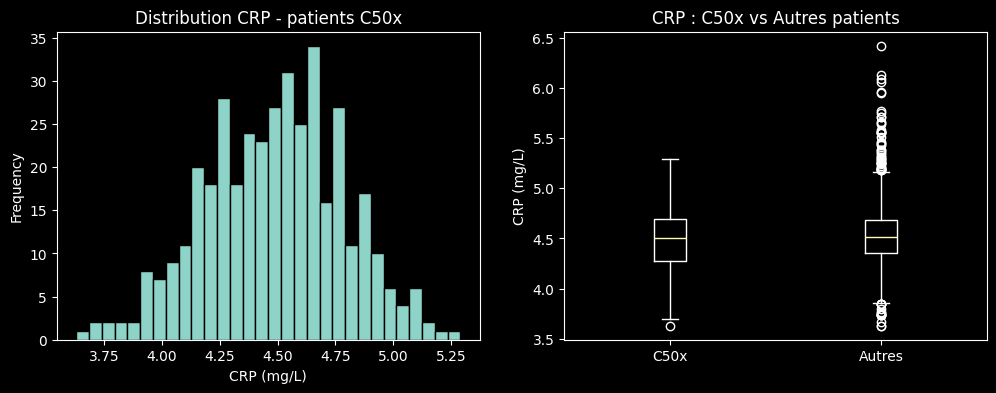

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
df_crp_c50['transformed_value'].plot.hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution CRP - patients C50x')
axes[0].set_xlabel('CRP (mg/L)')

axes[1].boxplot(
    [df_crp_c50['transformed_value'], df_crp_autres['transformed_value']],
    labels=['C50x', 'Autres']
)
axes[1].set_ylabel('CRP (mg/L)')
axes[1].set_title('CRP : C50x vs Autres patients')
plt.show()


In [44]:
df_crp_c50['groupe'] = 'C50x'
df_crp_autres['groupe'] = 'Autres'
df_compare = pd.concat([df_crp_c50, df_crp_autres])


alt.Chart(df_compare).mark_boxplot().encode(
    x=alt.X('groupe:N', title='Groupe'),
    y=alt.Y('transformed_value:Q', title='CRP (mg/L)'),
    color='groupe:N'
).properties(
    title='CRP : C50x vs Autres patients',
    width=300
)

/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_51026/2765715794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_crp_c50['groupe'] = 'C50x'
/var/folders/6l/sdcbwp596f9clmfcxlm_2ylh0000gn/T/ipykernel_51026/2765715794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_crp_autres['groupe'] = 'Autres'


alt.Chart(...)

In [45]:
# Patients uniques avec leur groupe et sexe
df_patients = df_compare.drop_duplicates('person_id')[['person_id', 'gender_source_value', 'groupe']]

# --- 1. Tableau croisé sexe × groupe ---
tableau = pd.crosstab(
    df_patients['gender_source_value'],
    df_patients['groupe'],
    margins=True
)
print(tableau)



groupe               Autres  C50x   All
gender_source_value                    
female                  560   393   953
male                    541     0   541
All                    1101   393  1494


In [46]:
# Visualisation Altair 
repartition = df_patients.groupby(['gender_source_value', 'groupe']).size().reset_index(name='nb_patients')

alt.Chart(repartition).mark_bar().encode(
    x=alt.X('gender_source_value:N', title='Sexe'),
    y=alt.Y('nb_patients:Q', title='Nombre de patients'),
    color=alt.Color('groupe:N', scale=alt.Scale(
        domain=['C50x', 'Autres'],
        range=['#e45756', '#4c78a8']
    )),
    xOffset='groupe:N'
).properties(
    title='Influence du sexe sur la présence en C50x',
    width=300
)


alt.Chart(...)

In [47]:
#  Test Chi² 
from scipy.stats import chi2_contingency

table = pd.crosstab(df_patients['gender_source_value'], df_patients['groupe'])
chi2, p, dof, _ = chi2_contingency(table)
print(f"Chi² = {chi2:.3f}, p-value = {p:.4f}")
print("→ Lien significatif entre sexe et C50x" if p < 0.05 else "→ Pas de lien significatif")


Chi² = 300.610, p-value = 0.0000
→ Lien significatif entre sexe et C50x


Deduplication proba

In [48]:
df_person = df_person_fix
df_dedup_proba = pd.read_pickle("datap/df_dedup_proba.pkl")

print(df_dedup_proba.head())
df_dedup_proba['prob'].describe()


     unique_person_id   person_id      prob
100        81076351.0  81292219.0  1.000000
48         86827620.0  87604616.0  1.000000
109        88836037.0  86178595.0  0.754593
70         84763748.0  82185488.0  1.000000
45         81097903.0  80952185.0  1.000000


count    117.000000
mean       0.693285
std        0.322495
min        0.032158
25%        0.425910
50%        0.865630
75%        1.000000
max        1.000000
Name: prob, dtype: float64

<Axes: ylabel='Density'>

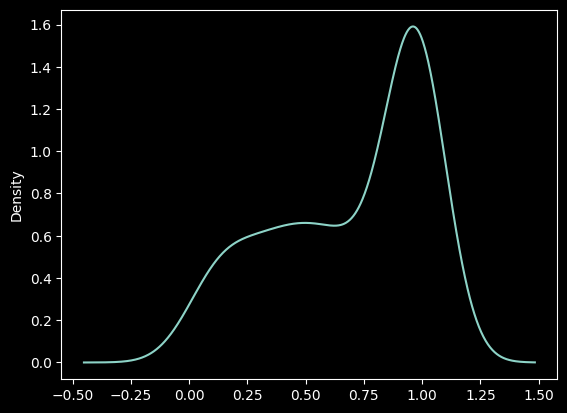

In [49]:
# Print de la densité:
df_dedup_proba['prob'].plot.density()

In [50]:
def deduplicate_proba(df_person: pd.DataFrame, df_dedup_proba: pd.DataFrame, score: int):
    #Only keep rows with a probability above the value score
    df_dedup_proba_score = df_dedup_proba[df_dedup_proba['prob'] > score]
    # Outer Join
    df_person_dedup_proba  = pd.merge(df_person, df_dedup_proba_score, on = 'person_id', how = 'outer')
    # Only unique ids in unique_person_id
    df_person_dedup_proba['unique_person_id'] = df_person_dedup_proba['unique_person_id'].fillna(df_person_dedup_proba['person_id'])
    # Only keep one row per patient
    df_person_dedup_proba = df_person_dedup_proba.drop_duplicates(['unique_person_id'], keep = 'first')
    return df_person_dedup_proba

In [51]:
df_person_dedup_proba_90 = deduplicate_proba(df_person, df_dedup_proba, score=0.90)
print(f"We have {df_person_dedup_proba_90.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.")

We have 1476 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.90.


In [52]:
df_person_dedup_proba_20 = deduplicate_proba(df_person, df_dedup_proba, score = 0.20)
print(f"We have {df_person_dedup_proba_20.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.")


We have 1426 unique patient ids in this dataset when using the probabilistic algorithm and a threshold of 0.20.


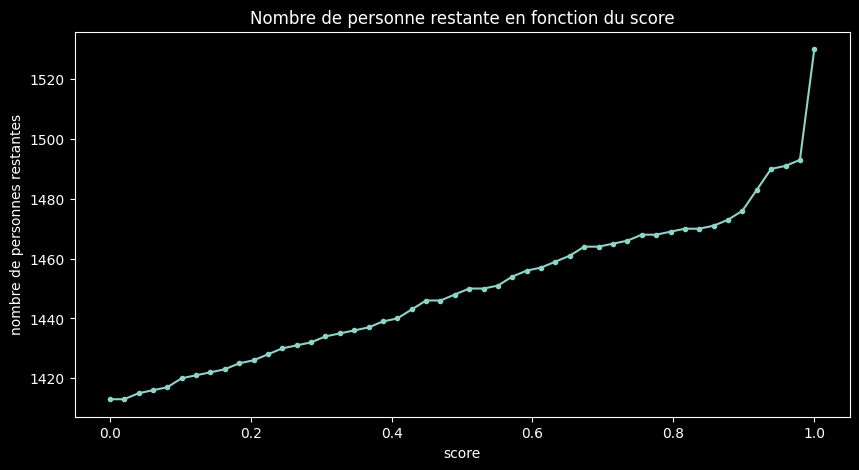

In [ ]:
# df_person.head()
# print(len(df_person)). 

threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score = t)
    n_remaining.append(dt["unique_person_id"].nunique())
    
plt.figure(figsize=(10, 5))
plt.plot(threshold, n_remaining, marker='o', markersize=3)
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")
plt.show()


Seuil optimal (elbow) : 0.980


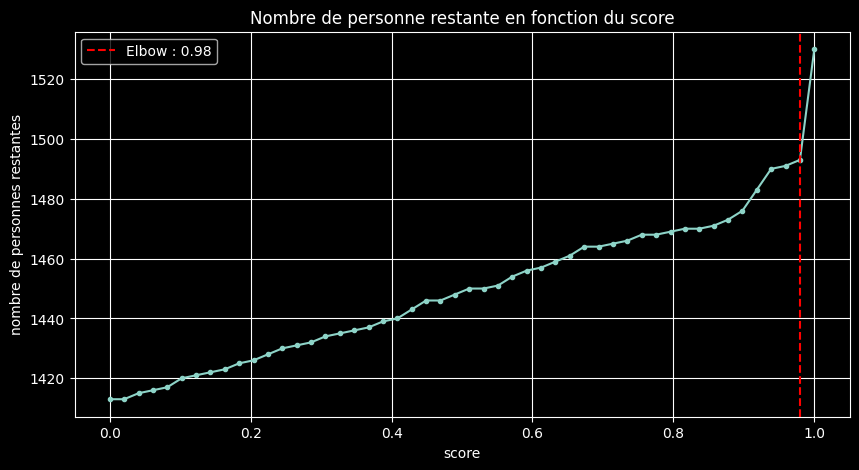

We have 1493 unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.


In [ ]:

# Utilisation de la méthode du coude pour trouver le meilleur score

threshold = np.linspace(0, 1, num=50)
n_remaining = []

for t in threshold:
    dt = deduplicate_proba(df_person, df_dedup_proba, score=t)
    n_remaining.append(dt["unique_person_id"].nunique())

# --- Elbow (dérivée seconde) ---
n = np.array(n_remaining)
d2 = np.diff(np.diff(n))
elbow_idx = np.argmax(d2) + 1
optimal_threshold = threshold[elbow_idx]

print(f"Seuil optimal (elbow) : {optimal_threshold:.3f}")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(threshold, n_remaining, marker='o', markersize=3)  
plt.axvline(x=optimal_threshold, color='red', linestyle='--',
            label=f"Elbow : {optimal_threshold:.2f}")
plt.title("Nombre de personne restante en fonction du score")
plt.xlabel("score")
plt.ylabel("nombre de personnes restantes")
plt.legend()
plt.grid(True)
plt.show()


df_person_dedup_proba_elbow = deduplicate_proba(df_person, df_dedup_proba, score = optimal_threshold)
print(f"We have {df_person_dedup_proba_elbow.unique_person_id.nunique()} unique patient ids in this dataset when using the probabilistic algorithm and a the optimal threshold.")
